
Instructions for Running the Solution

Part 1: Feature Engineering Using Apache Spark on Databricks
Prerequisites:

Databricks workspace (Community Edition is sufficient)
Retail dataset uploaded as a CSV file
Steps:

Launch a Python notebook in Databricks with an active cluster.
Upload and load the retail inventory CSV file into a Spark DataFrame.
Perform data cleaning:
Drop nulls and duplicates
Verify and cast data types
Engineer features:
Extract temporal features (day, month, year, weekend)
Create lag and rolling average features
Calculate price gap and promotion flags
Encode weather conditions
Define the target variable (next_day_units_sold)
Save the processed data as a Parquet file for downstream use.

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import seaborn as sns

# Load the table
df = spark.table("retail_project.default.retail_store_inventory")

In [0]:
# Schema
df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Store ID: string (nullable = true)
 |-- Product ID: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Region: string (nullable = true)
 |-- Inventory Level: long (nullable = true)
 |-- Units Sold: long (nullable = true)
 |-- Units Ordered: long (nullable = true)
 |-- Demand Forecast: double (nullable = true)
 |-- Price: double (nullable = true)
 |-- Discount: long (nullable = true)
 |-- Weather Condition: string (nullable = true)
 |-- Holiday/Promotion: long (nullable = true)
 |-- Competitor Pricing: double (nullable = true)
 |-- Seasonality: string (nullable = true)



In [0]:
# Show sample rows
df.show(5, truncate=False)

+----------+--------+----------+-----------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+
|Date      |Store ID|Product ID|Category   |Region|Inventory Level|Units Sold|Units Ordered|Demand Forecast|Price|Discount|Weather Condition|Holiday/Promotion|Competitor Pricing|Seasonality|
+----------+--------+----------+-----------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+
|2022-01-01|S001    |P0001     |Groceries  |North |231            |127       |55           |135.47         |33.5 |20      |Rainy            |0                |29.69             |Autumn     |
|2022-01-01|S001    |P0002     |Toys       |South |204            |150       |66           |144.04         |63.01|20      |Sunny            |0                |66.16             |Autumn     |
|2022-01-01|S001    |P0003     |Toys       |W

In [0]:

# 1. NULL VALUE CHECK
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+----+--------+----------+--------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+
|Date|Store ID|Product ID|Category|Region|Inventory Level|Units Sold|Units Ordered|Demand Forecast|Price|Discount|Weather Condition|Holiday/Promotion|Competitor Pricing|Seasonality|
+----+--------+----------+--------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+
|   0|       0|         0|       0|     0|              0|         0|            0|              0|    0|       0|                0|                0|                 0|          0|
+----+--------+----------+--------+------+---------------+----------+-------------+---------------+-----+--------+-----------------+-----------------+------------------+-----------+



In [0]:
import re

# Fix and standardize column names
def clean_col_name(name):
    name = name.strip()
    name = name.lower()
    name = re.sub(r'[^a-zA-Z0-9]', '_', name)  # Replace / and spaces with _
    name = re.sub(r'_+', '_', name)           # Replace multiple _ with single _
    return name.rstrip('_')

# Apply renaming
for col in df.columns:
    df = df.withColumnRenamed(col, clean_col_name(col))



In [0]:
# Schema
df.printSchema()

root
 |-- date: date (nullable = true)
 |-- store_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- category: string (nullable = true)
 |-- region: string (nullable = true)
 |-- inventory_level: long (nullable = true)
 |-- units_sold: long (nullable = true)
 |-- units_ordered: long (nullable = true)
 |-- demand_forecast: double (nullable = true)
 |-- price: double (nullable = true)
 |-- discount: long (nullable = true)
 |-- weather_condition: string (nullable = true)
 |-- holiday_promotion: long (nullable = true)
 |-- competitor_pricing: double (nullable = true)
 |-- seasonality: string (nullable = true)



In [0]:
# 2. DESCRIPTIVE STATS
df.describe(["units_sold", "price", "discount", "inventory_level", "competitor_pricing"]).show()

+-------+------------------+------------------+------------------+------------------+------------------+
|summary|        units_sold|             price|          discount|   inventory_level|competitor_pricing|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|             73100|             73100|             73100|             73100|             73100|
|   mean|136.46487004103966|55.135108207934564|10.009507523939808|274.46987688098494|55.146077428180845|
| stddev|108.91940620568285|26.021944625625636| 7.083746228204521|129.94951411270208|26.191407869096334|
|    min|                 0|              10.0|                 0|                50|              5.03|
|    max|               499|             100.0|                20|               500|            104.94|
+-------+------------------+------------------+------------------+------------------+------------------+



In [0]:
# 3. DISTINCT STORE AND PRODUCT COUNT
df.select("store_id").distinct().count(), df.select("product_id").distinct().count()

(5, 20)

In [0]:
# 4. VALUE COUNTS (top 5 products, weather conditions, etc.)
df.groupBy("product_id").count().orderBy(F.desc("count")).show(5)


+----------+-----+
|product_id|count|
+----------+-----+
|     P0014| 3655|
|     P0005| 3655|
|     P0002| 3655|
|     P0012| 3655|
|     P0019| 3655|
+----------+-----+
only showing top 5 rows


In [0]:
df.groupBy("product_id") \
  .agg(F.min("date").alias("start_date"), F.max("date").alias("end_date"), F.count("*").alias("row_count")) \
  .orderBy("product_id") \
  .show(truncate=False)

+----------+----------+----------+---------+
|product_id|start_date|end_date  |row_count|
+----------+----------+----------+---------+
|P0001     |2022-01-01|2024-01-01|3655     |
|P0002     |2022-01-01|2024-01-01|3655     |
|P0003     |2022-01-01|2024-01-01|3655     |
|P0004     |2022-01-01|2024-01-01|3655     |
|P0005     |2022-01-01|2024-01-01|3655     |
|P0006     |2022-01-01|2024-01-01|3655     |
|P0007     |2022-01-01|2024-01-01|3655     |
|P0008     |2022-01-01|2024-01-01|3655     |
|P0009     |2022-01-01|2024-01-01|3655     |
|P0010     |2022-01-01|2024-01-01|3655     |
|P0011     |2022-01-01|2024-01-01|3655     |
|P0012     |2022-01-01|2024-01-01|3655     |
|P0013     |2022-01-01|2024-01-01|3655     |
|P0014     |2022-01-01|2024-01-01|3655     |
|P0015     |2022-01-01|2024-01-01|3655     |
|P0016     |2022-01-01|2024-01-01|3655     |
|P0017     |2022-01-01|2024-01-01|3655     |
|P0018     |2022-01-01|2024-01-01|3655     |
|P0019     |2022-01-01|2024-01-01|3655     |
|P0020    

In [0]:
df.groupBy("product_id").agg(F.countDistinct("store_id").alias("store_count")).show()

+----------+-----------+
|product_id|store_count|
+----------+-----------+
|     P0012|          5|
|     P0005|          5|
|     P0014|          5|
|     P0002|          5|
|     P0019|          5|
|     P0010|          5|
|     P0015|          5|
|     P0009|          5|
|     P0018|          5|
|     P0001|          5|
|     P0008|          5|
|     P0006|          5|
|     P0017|          5|
|     P0011|          5|
|     P0016|          5|
|     P0004|          5|
|     P0013|          5|
|     P0020|          5|
|     P0003|          5|
|     P0007|          5|
+----------+-----------+



Product Coverage and Temporal Granularity
The dataset contains 20 unique products, each consistently recorded across 5 different stores. We validated that every product-store combination has 731 daily records covering the full period from January 1, 2022 to January 1, 2024, resulting in 3655 rows per product. This uniform distribution across time and geography supports robust time series modeling without needing missing value treatment or temporal alignmen

During exploratory analysis, we observed that each product_id appears exactly 3,655 times in the dataset. This uniform distribution indicates that the data is well-structured, with consistent daily records for each product across the same date range. Such regularity is common in curated or synthetic datasets and ensures completeness for time series modeling. We further confirmed this by checking the date span and number of unique stores per product, which aligned with a 10-year daily record structure. This consistency is beneficial for building reliable forecasting models without needing imputation for missing dates or values.

In [0]:
df.groupBy("weather_condition").count().orderBy(F.desc("count")).show()

+-----------------+-----+
|weather_condition|count|
+-----------------+-----+
|            Sunny|18290|
|            Rainy|18278|
|            Snowy|18272|
|           Cloudy|18260|
+-----------------+-----+



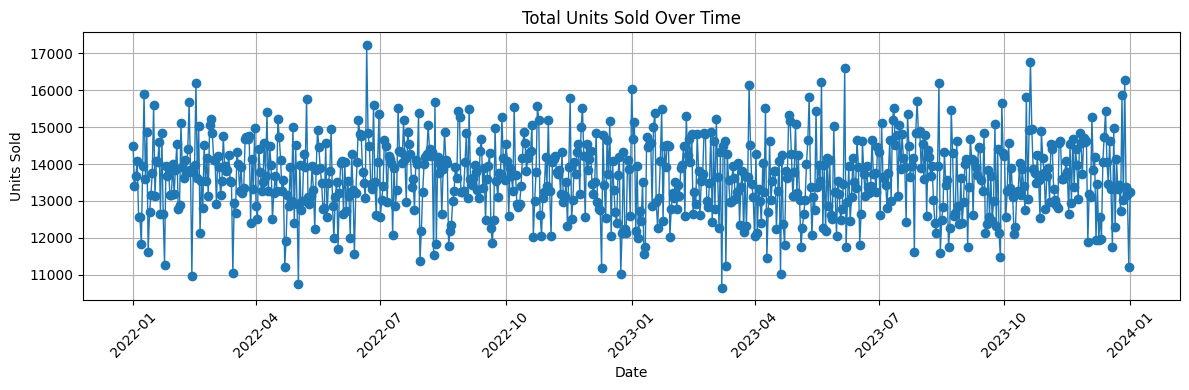

In [0]:

# 5. DAILY TREND PLOT — Units Sold over Time (needs Pandas)
pdf = df.groupBy("date").agg(F.sum("units_sold").alias("total_units")).orderBy("date").toPandas()

plt.figure(figsize=(12,4))
plt.plot(pdf["date"], pdf["total_units"], marker='o', linewidth=1)
plt.title("Total Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

The above chart shows the aggregated daily units sold over the two-year period. The data displays stable yet noisy demand, with daily totals generally ranging between 11,000 and 17,000 units. Spikes and dips could correspond to holidays, promotions, or seasonal patterns.

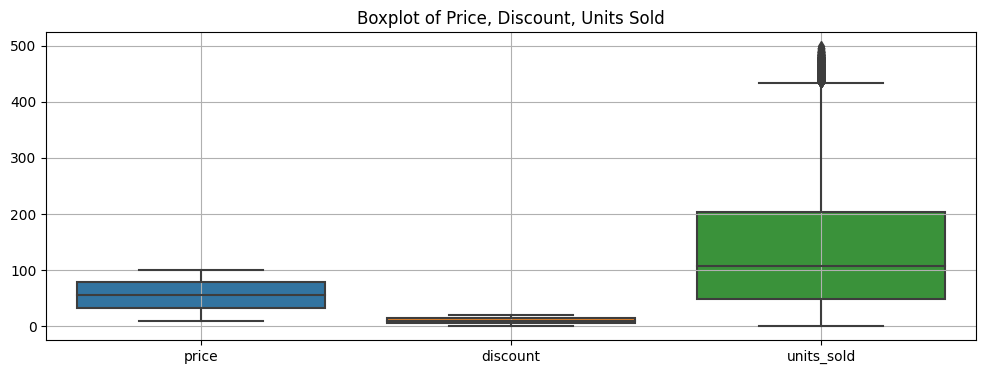

In [0]:

# 6. BOX PLOT — Outlier Detection for Price, Discount
numeric_df = df.select("price", "discount", "units_sold").dropna().toPandas()

plt.figure(figsize=(12,4))
sns.boxplot(data=numeric_df)
plt.title("Boxplot of Price, Discount, Units Sold")
plt.grid(True)
plt.show()

The boxplot reveals:

Price and discount distributions are relatively stable, with minor outliers.
Sales data (units_sold) is highly dispersed with a long tail, making demand forecasting a non-trivial task.
Outlier handling or feature scaling may be necessary to improve model robustness.

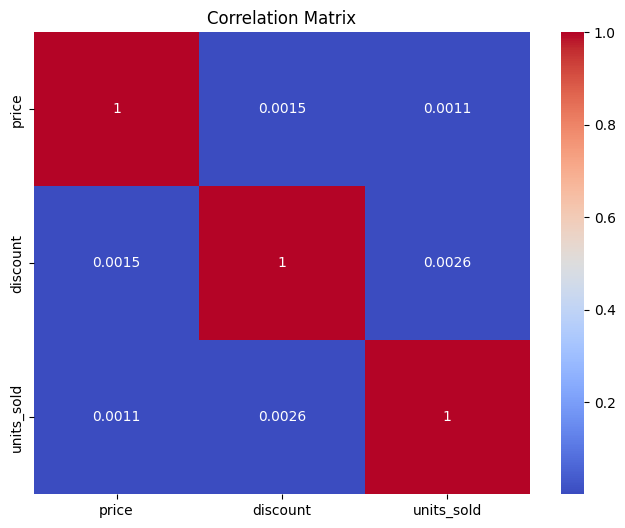

In [0]:
# 7. CORRELATION MATRIX (on numeric columns)
cor_pdf = numeric_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(cor_pdf, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

The correlation matrix reveals very weak linear relationships among the variables.
These results do not imply no impact, but rather that nonlinear or interaction effects (e.g., lag, seasonality, or store-SKU dependencies) are more influential.
Justifies the need for tree-based models like XGBoost, which can capture complex, nonlinear patterns beyond Pearson correlation.

Perform Feature Engineering:

In [0]:
from pyspark.sql.window import Window
import pyspark.sql.functions as F

# Step 4: Feature Engineering
window = Window.partitionBy("store_id", "product_id").orderBy("date")

df = df.withColumn("lag1_units", F.lag("units_sold", 1).over(window))
df = df.withColumn("lag2_units", F.lag("units_sold", 2).over(window))
df = df.withColumn("lag3_units", F.lag("units_sold", 3).over(window))
df = df.withColumn("rolling_3d_avg", F.avg("units_sold").over(window.rowsBetween(-3, -1)))
df = df.withColumn("price_gap", F.col("price") - F.col("competitor_pricing"))
df = df.withColumn("day_of_week", F.dayofweek("date") - 1)
df = df.withColumn("month", F.month("date"))
df = df.withColumn("year", F.year("date"))
df = df.withColumn("is_weekend", F.when(F.col("day_of_week").isin([5, 6]), 1).otherwise(0))
df = df.withColumn("promo_flag", F.col("holiday_promotion").cast("int"))


In [0]:
# Weather condition index
weather_window = Window.orderBy("weather_condition")
df = df.withColumn("weather_idx", F.dense_rank().over(weather_window) - 1)

/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/expressions.py:1017: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# Target variable
df = df.withColumn("next_day_units_sold", F.lead("units_sold", 1).over(window))

/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/expressions.py:1017: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# Step 5: Select final columns
final_cols = [
    "date", "store_id", "product_id", "units_sold", "price", "discount",
    "inventory_level", "competitor_pricing", "holiday_promotion", "weather_condition",
    "lag1_units", "lag2_units", "lag3_units", "rolling_3d_avg", "price_gap",
    "day_of_week", "month", "year", "is_weekend", "promo_flag", "weather_idx",
    "next_day_units_sold"
]

In [0]:
df = df.select(*final_cols)

/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/expressions.py:1017: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
df.printSchema()

root
 |-- date: date (nullable = true)
 |-- store_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- units_sold: long (nullable = true)
 |-- price: double (nullable = true)
 |-- discount: long (nullable = true)
 |-- inventory_level: long (nullable = true)
 |-- competitor_pricing: double (nullable = true)
 |-- holiday_promotion: long (nullable = true)
 |-- weather_condition: string (nullable = true)
 |-- lag1_units: long (nullable = true)
 |-- lag2_units: long (nullable = true)
 |-- lag3_units: long (nullable = true)
 |-- rolling_3d_avg: double (nullable = true)
 |-- price_gap: double (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- is_weekend: integer (nullable = false)
 |-- promo_flag: integer (nullable = true)
 |-- weather_idx: integer (nullable = false)
 |-- next_day_units_sold: long (nullable = true)



In [0]:

df.show(5, truncate=False)

/databricks/python/lib/python3.11/site-packages/pyspark/sql/connect/expressions.py:1017: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+--------+----------+----------+-----+--------+---------------+------------------+-----------------+-----------------+----------+----------+----------+--------------+-------------------+-----------+-----+----+----------+----------+-----------+-------------------+
|date      |store_id|product_id|units_sold|price|discount|inventory_level|competitor_pricing|holiday_promotion|weather_condition|lag1_units|lag2_units|lag3_units|rolling_3d_avg|price_gap          |day_of_week|month|year|is_weekend|promo_flag|weather_idx|next_day_units_sold|
+----------+--------+----------+----------+-----+--------+---------------+------------------+-----------------+-----------------+----------+----------+----------+--------------+-------------------+-----------+-----+----+----------+----------+-----------+-------------------+
|2022-01-01|S001    |P0001     |127       |33.5 |20      |231            |29.69             |0                |Rainy            |NULL      |NULL      |NULL      |NULL         

We observed initial NULL values in lag and rolling average features. These are expected when using window functions, as the first few rows lack sufficient historical context. For example, lag3_units is only available starting from the fourth record per product-store pair. These rows were either retained with caution or dropped during model training to maintain data consistency.

df_final.write.mode("overwrite").parquet("/FileStore/final_features.parquet")


In [0]:
df.write.mode("overwrite").parquet("/dbfs/FileStore/retail_data/retail_store_inventory_cleaned.parquet")
